# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [51]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [52]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [53]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [54]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [55]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [56]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [57]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [58]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [59]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [60]:
# cantidad de nulos para users
print('Cantidad de valores nulos',users.isna().sum())
print('Proporción de valores nulos',users.isna().mean())

Cantidad de valores nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [61]:
# cantidad de nulos para usage
print('Cantidad de valores nulos',usage.isna().sum())
print('Proporción de valores nulos',usage.isna().mean())

Cantidad de valores nulos id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  R// Tabla USERS
    city: 469 valores nulos → 11.73%
    churn_date: 3534 valores nulos → 88.35%
    Las demás columnas no tienen valores faltantes.

    Tabla USAGE
    date: 50 valores nulos → 0.13%
    duration: 22076 valores nulos → 55.19%
    length: 17896 valores nulos → 44.74%
    Las columnas id, user_id y type no presentan valores faltantes.
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  R// Para USERS:
    city (11.73%) se peude Imputar,reemplazando por:
    "Unknown" si es categórica,o la ciudad más frecuente (moda).
    churn_date (88.35%) se podria: Ignorar o reinterpretar.Probablemente significa que el usuario no canceló el servicio. No conviene eliminar ni imputar arbitrariamente.

    Para USAGE:
    date (0.13%) se puede Eliminar filas. La proporción es mínima y la fecha suele ser importante.
    duration (55.19%) dependiendo del contexto:
    -si el tipo de uso no requiere duración (ej. mensajes), podría ignorarse;
    -si debería existir, entonces habría que investigar antes de imputar.
    length (44.74%) tambien depende del contexto:
    - probablemente aplica solo a ciertos tipos de eventos, podría mantenerse como NaN

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [62]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...
  Para USERS_ID podemos observar que no hay valores faltantes, debido a la natuaraleza de los datos la desviacion (std) es alta.
  por otro lado en AGE tiene un problema claro de calidad de datos debido al valor -999.
Ese valor distorsiona mucho la media y la desviación estándar

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [63]:
#explorar columnas categóricas de users
print("Valores únicos en 'city':")
print(users['city'].unique())

print("\nConteo de valores en 'city':")
print(users['city'].value_counts())

print("\nConteo de valores en 'plan':")
print(users['plan'].value_counts())

Valores únicos en 'city':
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo de valores en 'city':
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Conteo de valores en 'plan':
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` encontramos una problema de calidad de datos:? representa un valor desconocido o mal capturado, NaN indica valores faltantes reales, también hay mezcla de formatos:
Algunas ciudades están completas (Bogotá, Medellín, Cali) y otras usan abreviaturas (CDMX, GDL, MTY)
- La columna `plan` tenemos que No hay valores faltantes aparentes, Es una variable categórica binaria y Existe desbalance moderado:
~65% Básico
~35% Premium

In [64]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` se peude observar que es una variable categórica con solo dos categorías, No se observan valores faltantes ni categorías inválidas, La distribución es relativamente equilibrada:
55% text
45% call

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

R// Columna age:
Valor inválido detectado: -999 una edad negativa no es válida.
Probablemente se utilizó como código para representar datos faltantes.
Acción recomendada: Reemplazar -999 por NaN.
Luego: imputar con la mediana (47) o eliminar los registros si son pocos.

Columna city:
Valores problemáticos: ? , NaN
Problema: ? funciona como un sentinel para datos desconocidos.
NaN representa valores faltantes reales.
Acción recomendada:Convertir ? a NaN.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [65]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [66]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [67]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, teniendo en cuenta que los registros van hasta el año 2024 podemos ver que hay 40 datos con el año 2026 lo cual podria ser un error de digitacion 

In [68]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los datos son homogeneos en fecha de 2024 cde tipo date.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
  R// Los 40 registros con fecha 2026 probablemente corresponden a errores de digitación,problemas en el formato de fechas, registros corruptos, o datos de prueba.

Dado que representan apenas cerca del 1% del dataset, las opciones más recomendables son:
Eliminar esos registros, Es la opción más segura si no se puede corregir la fecha real.
Evita introducir ruido en el análisis.
Convertirlos a valores faltantes (NaN)

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [69]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [70]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [71]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].replace(2026, pd.NA)

# Verificar cambios
users['reg_date'].value_counts(dropna=False)


2026-05-10 00:00:00.000000000    40
2023-12-20 18:33:45.506376600     1
2022-11-21 17:58:06.571642912     1
2024-06-20 09:50:54.463615904     1
2022-05-22 00:23:45.956489122     1
                                 ..
2022-07-29 04:44:06.661665416     1
2022-02-22 00:36:43.750937734     1
2022-10-31 09:22:49.242310580     1
2022-09-24 16:46:48.702175544     1
2022-03-28 12:38:20.975243811     1
Name: reg_date, Length: 3961, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [72]:
# Verificación MAR en usage (Missing At Random) para duration
# Revisar nulos en duration según type
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

# Conteo de nulos y no nulos
pd.crosstab(usage['type'], usage['duration'].isna())

duration,False,True
type,,
call,17908,0
text,16,22076


In [73]:
# Verificación MAR en usage (Missing At Random) para length
# Revisar nulos en length según type
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

# Conteo de nulos y no nulos
pd.crosstab(usage['type'], usage['length'].isna())

length,False,True
type,,
call,12,17896
text,22092,0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores faltantes en duration dependen claramente de la variable type.

Para call, prácticamente todos los registros tienen duración.
Para text, casi todos los registros tienen duration nulo.

Esto indica que los nulos no ocurren al azar, sino que están relacionados con el tipo de interacción. Por eso, los nulos en duration representan una ausencia esperada de información y no un error de captura.

mientras que en length dependen claramente de la variable type.

Para text, todos los registros tienen longitud (length).
Para call, casi todos los registros tienen length nulo.
Por tanto, los valores nulos representan una ausencia lógica de información y no un problema de calidad de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [74]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [75]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [76]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [77]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [78]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

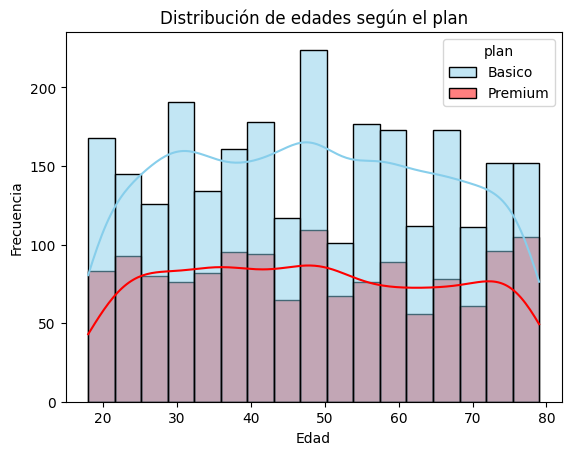

In [79]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    kde=True,
    palette=["skyblue", "red"]
)

plt.title("Distribución de edades según el plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- La distribución es aproximadamente simétrica.
- No se observa una diferencia muy marcada entre usuarios Básico y Premium.
- Ambos planes concentran usuarios principalmente entre edades medias.

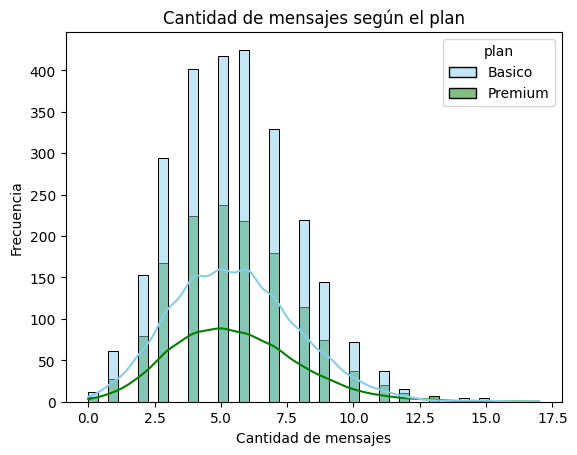

In [80]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    kde=True,
    palette=["skyblue", "green"]
)

plt.title("Cantidad de mensajes según el plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución está sesgada a la derecha.
- La mayoría de usuarios envían pocos mensajes y pocos usuarios envían muchos.
- Los usuarios Premium parecen tener ligeramente mayor actividad de mensajería

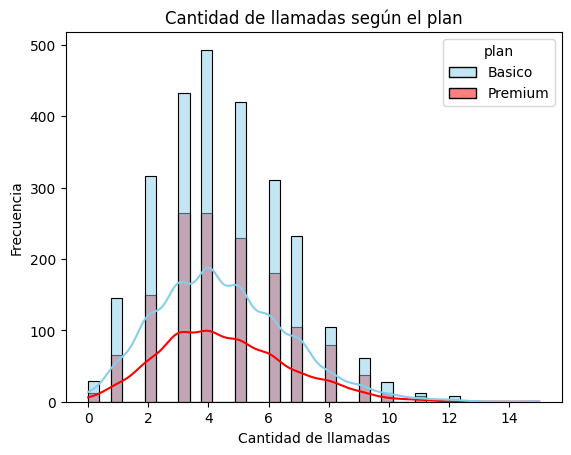

In [81]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    kde=True,
    palette=["skyblue", "red"]
)

plt.title("Cantidad de llamadas según el plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución presenta sesgo a la derecha.
- La mayoría de usuarios realizan pocas llamadas.
- No se observa un patrón extremadamente diferente entre ambos planes.

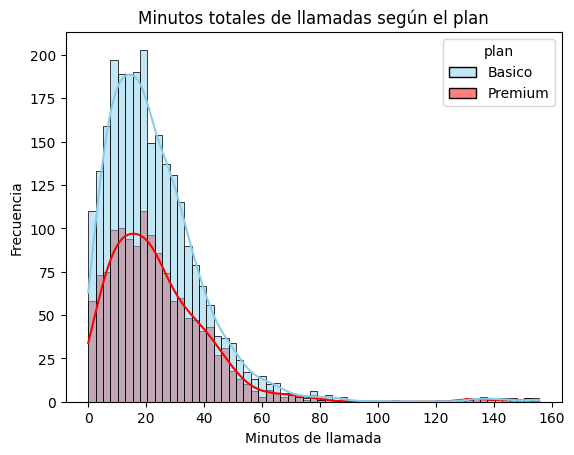

In [82]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    kde=True,
    palette=["skyblue", "red"]
)

plt.title("Minutos totales de llamadas según el plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
 - La distribución está sesgada a la derecha.
 - La mayoría de usuarios consume pocos minutos de llamadas.
 - Los usuarios Premium tienden a acumular más minutos de llamada que los usuarios Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

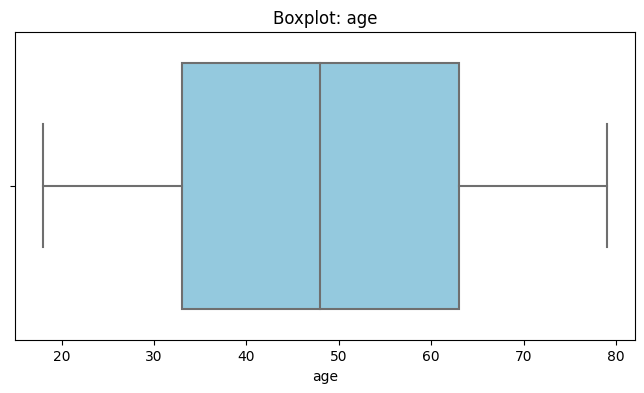

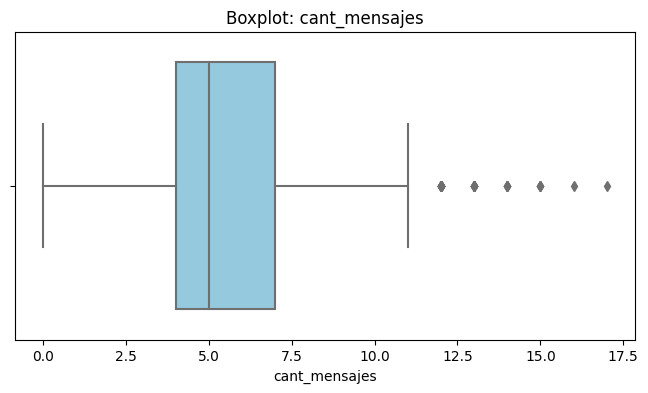

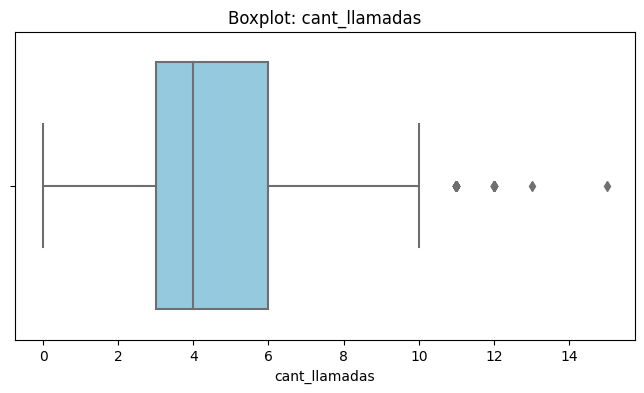

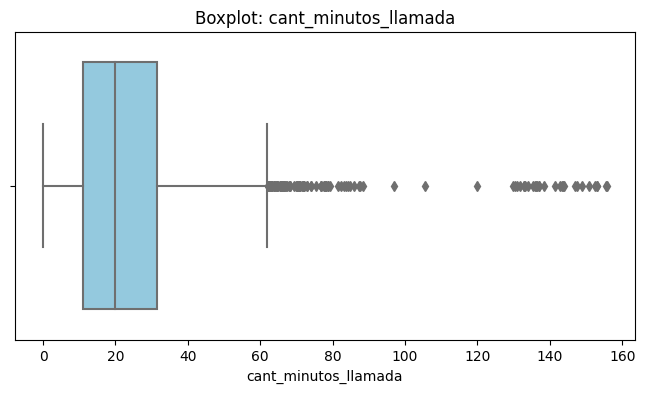

In [83]:
# Visualizando usando BoxPlot 

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue'
    )
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 

-Age: No presenta outliers importantes después de reemplazar el valor inválido -999. La distribución de edades se encuentra dentro de rangos razonables.
-cant_mensajes: presenta outliers hacia la derecha. Existen usuarios que envían una cantidad de mensajes considerablemente mayor al resto.
-cant_llamadas: presenta outliers hacia la derecha. Algunos usuarios realizan muchas más llamadas que la mayoría.
-cant_minutos_llamada: presenta outliers claros hacia la derecha. Hay usuarios con un consumo de minutos muy elevado comparado con el comportamiento general.

In [84]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f'\nColumna: {col}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')


Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575


In [85]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes:
Se recomienda mantener los outliers, porque representan usuarios con alta actividad de mensajería y no parecen errores de captura. El valor máximo (17) no es extremadamente lejano respecto al resto de la distribución.
cant_llamadas:
También se recomienda mantener los outliers, ya que los usuarios con muchas llamadas pueden corresponder a comportamientos reales de uso. Además, el máximo (15) sigue siendo razonable comparado con la media y los cuartiles.
cant_minutos_llamada:
Presenta outliers más notorios debido al máximo (155.69) frente a una media cercana a 23. Sin embargo, es recomendable mantenerlos, porque pueden representar usuarios intensivos del servicio y no necesariamente errores. Solo deberían tratarse si afectan modelos estadísticos o generan sesgos importantes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [86]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10) &
    (user_profile['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'
] = 'Uso medio'


In [87]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.


**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [88]:
# Crear columna grupo_edad

user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

user_profile.loc[
    (user_profile['age'] < 60) &
    (user_profile['grupo_edad'] != 'Joven'),
    'grupo_edad'
] = 'Adulto'


In [89]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

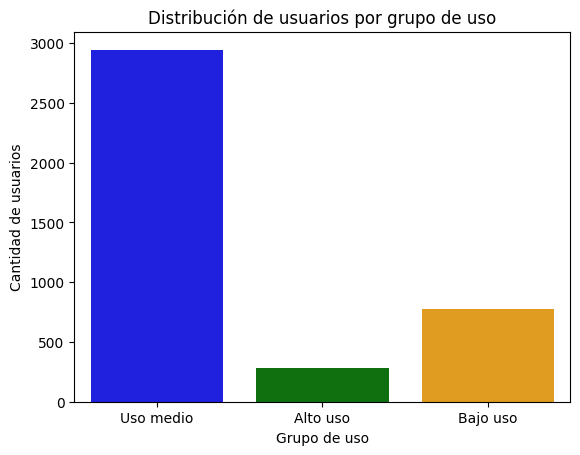

In [90]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['blue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

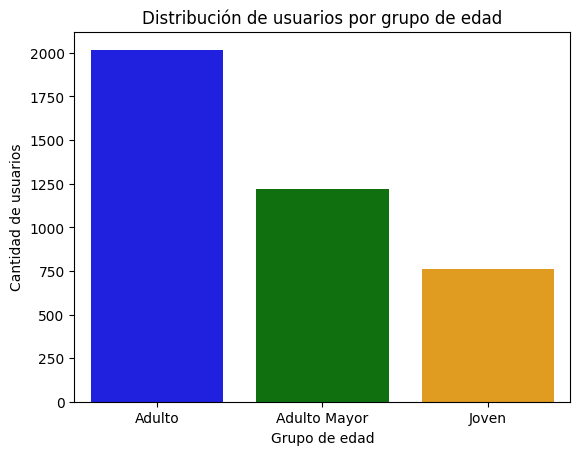

In [91]:
# Visualización de los segmentos por edad

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['blue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Se identificaron varios problemas de calidad de datos:

Valores inválidos en age
Existía el valor sentinel -999, que representa una edad imposible.
Este valor afectaba las estadísticas descriptivas (media y desviación estándar).
Se reemplazó por la mediana de la columna para evitar distorsiones.

Valores inválidos y faltantes en city
Se encontraron registros con ? y valores nulos (NaN), "?" funcionaba como un sentinel para datos desconocidos con un aproximado de 96 registros con ? y se reemplazaron por pd.NA.

"Fechas" fuera de rango en reg_date, y se detectaron registros con el año 2026, aunque los datos solo llegan hasta 2024, representaban 40 registros y se marcaron como nulos (NA).

Valores nulos en duration y length
Los nulos no eran errores sino valores esperados: 
-duration era nulo principalmente para mensajes (text)
-length era nulo principalmente para llamadas (call)
-Estos casos fueron clasificados como datos MAR (Missing At Random) y se mantuvieron como nulos.

Segmentación por edad

-Joven: menores de 30 años.
-Adulto: entre 30 y 59 años.
-Adulto Mayor: 60 años o más.

Segmentación por nivel de uso
Bajo uso: Pocas llamadas y pocos mensajes, son Usuarios menos activos.
Uso medio: Consumo moderado de llamadas y mensajes, representan usuarios regulares.
Alto uso: Gran cantidad de mensajes y llamadas, son usuarios intensivos del servicio.

Comportamientos observados
Los usuarios Premium tienden a concentrar mayor actividad en llamadas y minutos consumidos.
Los usuarios de uso alto probablemente generan mayor consumo y dependencia del servicio.
Los usuarios jóvenes parecen usar más mensajería.
Los adultos y adultos mayores presentan un comportamiento más equilibrado entre llamadas y mensajes.

Los segmentos mas valiosos:

Usuarios Premium de alto uso: Generan mayor consumo del servicio, Probablemente representan mayores ingresos recurrentes, Tienen alta interacción con la plataforma.

Usuarios con alto consumo de minutos: Pueden beneficiarse de planes especializados, Tienen mayor probabilidad de adquirir servicios adicionales.

Usuarios jóvenes con alta mensajería: Representan una oportunidad para paquetes digitales y redes sociales.

Estos segmentos son estratégicos porque: utilizan intensamente los servicios, pueden generar mayor rentabilidad, y tienen potencial para fidelización.

Se encontraron outliers principalmente en: cant_mensajes, cant_llamadas, cant_minutos_llamada
para el negocio pueden aumentar costos operativos si los planes son ilimitados.
También representan oportunidades para: planes premium avanzados, paquetes ilimitados o estrategias de fidelización. No se eliminaron porque parecen comportamientos reales y no errores de datos.

Recomendaciones:

Crear planes segmentados específicos para:

usuarios intensivos en llamadas,
usuarios enfocados en mensajería,
y usuarios de bajo consumo.

Diseñar planes Premium más flexibles: Agregar beneficios escalables según consumo real.

Crear paquetes para usuarios jóvenes: Más datos, mensajería ilimitada y beneficios digitales.

Ofrecer planes corporativos o ilimitados: Para usuarios con consumo extremo de minutos y llamadas.

Implementar campañas de upselling: Migrar usuarios Básico con uso medio/alto hacia Premium.

Monitorear continuamente outliers, para detectar oportunidades de negocio o posibles fraudes/anomalías.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se encontraron valores inválidos en age (-999), los cuales fueron reemplazados por la mediana para evitar distorsiones estadísticas.
En city existían valores inconsistentes (?) y datos faltantes (NaN), que fueron tratados como valores nulos.
Se detectaron registros con fechas futuras (2026) en reg_date, aunque los datos solo debían llegar hasta 2024.
Las columnas duration y length presentaban nulos lógicos dependiendo del tipo de interacción (call o text), por lo que se mantuvieron como valores faltantes válidos.


🔍 **Segmentos por Edad**
Los usuarios fueron clasificados en Jóvenes, Adultos y Adultos Mayores según su edad.
Los usuarios jóvenes tienden a tener mayor actividad de mensajería, mientras que los adultos presentan un uso más equilibrado entre llamadas y mensajes.


📊 **Segmentos por Nivel de Uso**

Se identificaron usuarios de Bajo uso, Uso medio y Alto uso según la cantidad de llamadas y mensajes.
Los usuarios Premium muestran una tendencia a consumir más minutos y generar mayor actividad general.
También se detectaron usuarios intensivos (outliers) con niveles de consumo considerablemente superiores al promedio.


➡️ Esto sugiere que existen distintos perfiles de clientes con necesidades y comportamientos de consumo diferentes, por lo que una estrategia única de planes puede no ser la más eficiente para maximizar ingresos y satisfacción.


💡 **Recomendaciones**
Diseñar planes segmentados según comportamiento de uso: planes enfocados en mensajería, llamadas o consumo intensivo.
Crear beneficios adicionales para usuarios Premium y de alto consumo para mejorar fidelización.
Implementar estrategias de upselling para migrar usuarios de uso medio desde Básico hacia Premium.
Monitorear continuamente los outliers para identificar oportunidades de negocio, clientes estratégicos o posibles anomalías.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`